## Import библиотек и модулей


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import json

from pathlib import Path
import re
from datetime import datetime, timedelta
# --- Настройка путей и sys.path ---
# Добавляем корневую директорию проекта в sys.path для импорта кастомных модулей
PROJECT_ROOT = Path().cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.config import path_config, database
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from concurrent.futures import ThreadPoolExecutor, as_completed
from sqlalchemy import text
import os, sys
import re
from datetime import datetime, timedelta
# --- Настройка путей и sys.path ---
# Добавляем корневую директорию проекта в sys.path для импорта кастомных модулей
PROJECT_ROOT = Path().cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.logger import logger
from src.database import clickhouse_engine

2026-03-18 16:04:37,928 | my_logger - INFO - ✅ ClickHouse engine создан | /data/aturov/universal_control_group/src/database.py:21


In [2]:
DATA_START = "2026-02-01" # --- Дата начала периода для анализа (включительно) ---

df_final = pd.read_parquet(path_config.data_processed_path / f"ukg_eligible_final_{DATA_START}.parquet")

## EDA для разбиения на control / test

В этом блоке мы:

- проверяем качество месячного среза перед экспериментом
- создаем детерминированный сплит по `SUBS_ID`
- считаем `SRM`, `SMD`, `KS`, `chi-square` и `FDR`
- строим графики для быстрой интерпретации баланса

Важно: `KS` здесь используется как дополнительная диагностика распределений, а не как единственный критерий корректности разбиения.

In [3]:
import warnings
import seaborn as sns

from IPython.display import Markdown, display
from scipy import stats

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

CONTROL_SHARE = 0.10
SPLIT_SALT = "ukg_split_v1"
BALANCE_SAMPLE_PER_GROUP = 120_000
KS_SAMPLE_PER_GROUP = 75_000
PLOT_SAMPLE_PER_GROUP = 40_000
MAX_CATEGORY_LEVELS = 12
TOP_MISSING_FEATURES = 15
TOP_NUMERIC_PLOTS = 4
TOP_CATEGORICAL_PLOTS = 4
ID_CANDIDATES = ["SUBS_ID", "subscriber_id", "subs_id", "SUBSCRIBER_ID", "CTN"]


def detect_id_column(df: pd.DataFrame, candidates: list[str] | None = None) -> str:
    candidates = candidates or ID_CANDIDATES
    for column in candidates:
        if column in df.columns:
            return column
    raise ValueError(f"Не найден идентификатор абонента. Проверенные варианты: {candidates}")



def infer_feature_buckets(df: pd.DataFrame, id_col: str) -> tuple[list[str], list[str], list[str]]:
    date_like_cols = []
    for column in df.columns:
        column_upper = column.upper()
        if column == id_col:
            continue
        if "DATE" in column_upper or column_upper.endswith("_DT") or column_upper == "DT":
            date_like_cols.append(column)

    numeric_cols = [
        column
        for column in df.columns
        if column != id_col
        and column not in date_like_cols
        and pd.api.types.is_numeric_dtype(df[column])
    ]
    categorical_cols = [
        column
        for column in df.columns
        if column != id_col
        and column not in date_like_cols
        and column not in numeric_cols
    ]
    return numeric_cols, categorical_cols, date_like_cols



def assign_experiment_group(series: pd.Series, control_share: float = CONTROL_SHARE, salt: str = SPLIT_SALT) -> tuple[pd.Series, pd.Series]:
    payload = series.astype("string").fillna("MISSING") + "|" + salt
    hash_values = pd.util.hash_pandas_object(payload, index=False).astype("uint64")
    threshold = int(np.iinfo("uint64").max * control_share)
    groups = np.where(hash_values.to_numpy() <= threshold, "control", "test")
    return pd.Series(groups, index=series.index, name="experiment_group"), pd.Series(hash_values, index=series.index, name="split_hash")



def benjamini_hochberg(p_values: pd.Series | list[float]) -> pd.Series:
    p_series = pd.Series(p_values, dtype="float64")
    valid = p_series.dropna()
    result = pd.Series(np.nan, index=p_series.index, dtype="float64")
    if valid.empty:
        return result

    order = np.argsort(valid.to_numpy())
    ranked_index = valid.index[order]
    ranked_values = valid.loc[ranked_index].to_numpy()
    n_tests = len(ranked_values)
    adjusted = ranked_values * n_tests / np.arange(1, n_tests + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    result.loc[ranked_index] = adjusted
    return result



def calculate_smd(control: pd.Series, test: pd.Series) -> float:
    control_clean = pd.to_numeric(control, errors="coerce").dropna()
    test_clean = pd.to_numeric(test, errors="coerce").dropna()
    if len(control_clean) < 2 or len(test_clean) < 2:
        return np.nan

    pooled_variance = (control_clean.var(ddof=1) + test_clean.var(ddof=1)) / 2
    if pd.isna(pooled_variance) or pooled_variance == 0:
        if np.isclose(control_clean.mean(), test_clean.mean()):
            return 0.0
        return np.nan
    return (test_clean.mean() - control_clean.mean()) / np.sqrt(pooled_variance)



def reduce_categories(series: pd.Series, max_levels: int = MAX_CATEGORY_LEVELS) -> pd.Series:
    prepared = series.astype("string").fillna("MISSING")
    unique_count = prepared.nunique(dropna=False)
    if unique_count <= max_levels:
        return prepared

    top_levels = prepared.value_counts(dropna=False).head(max_levels - 1).index
    return prepared.where(prepared.isin(top_levels), other="OTHER")



def build_stratified_sample(df: pd.DataFrame, group_col: str, sample_per_group: int, random_state: int = 42) -> pd.DataFrame:
    parts = []
    for group_name in ["control", "test"]:
        group_part = df[df[group_col] == group_name]
        sample_size = min(sample_per_group, len(group_part))
        parts.append(group_part.sample(sample_size, random_state=random_state))
    return pd.concat(parts, axis=0).reset_index(drop=True)



def srm_test(group_series: pd.Series, control_share: float = CONTROL_SHARE) -> dict:
    counts = group_series.value_counts()
    observed = np.array([counts.get("control", 0), counts.get("test", 0)], dtype="float64")
    total = observed.sum()
    expected = np.array([control_share, 1 - control_share], dtype="float64") * total
    chi2_stat = ((observed - expected) ** 2 / expected).sum()
    p_value = stats.chi2.sf(chi2_stat, df=1)
    return {
        "control_count": int(observed[0]),
        "test_count": int(observed[1]),
        "control_share_observed": observed[0] / total,
        "test_share_observed": observed[1] / total,
        "expected_control_share": control_share,
        "chi2_stat": chi2_stat,
        "p_value": p_value,
    }



def analyze_numeric_balance(df: pd.DataFrame, group_col: str, numeric_cols: list[str]) -> pd.DataFrame:
    results = []
    control_mask = df[group_col] == "control"
    test_mask = df[group_col] == "test"

    for column in numeric_cols:
        control = pd.to_numeric(df.loc[control_mask, column], errors="coerce")
        test = pd.to_numeric(df.loc[test_mask, column], errors="coerce")
        control_non_null = control.dropna()
        test_non_null = test.dropna()

        if control_non_null.empty or test_non_null.empty:
            continue

        control_ks = control_non_null.sample(min(KS_SAMPLE_PER_GROUP, len(control_non_null)), random_state=42)
        test_ks = test_non_null.sample(min(KS_SAMPLE_PER_GROUP, len(test_non_null)), random_state=42)
        ks_stat, p_value = stats.ks_2samp(control_ks, test_ks, alternative="two-sided", method="auto")
        smd_value = calculate_smd(control_non_null, test_non_null)

        results.append({
            "feature": column,
            "feature_type": "numeric",
            "missing_pct": df[column].isna().mean() * 100,
            "control_mean": control_non_null.mean(),
            "test_mean": test_non_null.mean(),
            "control_median": control_non_null.median(),
            "test_median": test_non_null.median(),
            "effect_size": abs(smd_value),
            "effect_size_name": "abs_smd",
            "direction": smd_value,
            "ks_stat": ks_stat,
            "p_value": p_value,
            "non_null_control": len(control_non_null),
            "non_null_test": len(test_non_null),
        })

    return pd.DataFrame(results)



def analyze_categorical_balance(df: pd.DataFrame, group_col: str, categorical_cols: list[str]) -> pd.DataFrame:
    results = []
    for column in categorical_cols:
        prepared = reduce_categories(df[column], max_levels=MAX_CATEGORY_LEVELS)
        contingency = pd.crosstab(prepared, df[group_col])
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue

        chi2_stat, p_value, _, _ = stats.chi2_contingency(contingency)
        total = contingency.to_numpy().sum()
        effect_denom = max(1, min(contingency.shape[0] - 1, contingency.shape[1] - 1))
        cramers_v = np.sqrt((chi2_stat / total) / effect_denom)

        mode_by_group = (
            pd.crosstab(prepared, df[group_col], normalize="columns")
            .idxmax()
            .to_dict()
        )

        results.append({
            "feature": column,
            "feature_type": "categorical",
            "missing_pct": df[column].isna().mean() * 100,
            "control_mean": np.nan,
            "test_mean": np.nan,
            "control_median": np.nan,
            "test_median": np.nan,
            "effect_size": cramers_v,
            "effect_size_name": "cramers_v",
            "direction": np.nan,
            "ks_stat": np.nan,
            "p_value": p_value,
            "non_null_control": int((df[group_col] == "control").sum()),
            "non_null_test": int((df[group_col] == "test").sum()),
            "control_mode": mode_by_group.get("control"),
            "test_mode": mode_by_group.get("test"),
            "levels_after_bucketing": contingency.shape[0],
        })

    return pd.DataFrame(results)



def add_balance_flags(balance_report: pd.DataFrame) -> pd.DataFrame:
    report = balance_report.copy()
    report["fdr_q_value"] = benjamini_hochberg(report["p_value"])
    report["significant_after_fdr"] = report["fdr_q_value"] < 0.05
    report["practical_imbalance"] = np.where(
        report["feature_type"] == "numeric",
        report["effect_size"] >= 0.10,
        report["effect_size"] >= 0.10,
    )
    return report.sort_values(["practical_imbalance", "effect_size", "p_value"], ascending=[False, False, True])



def print_balance_commentary(split_stats: dict, balance_report: pd.DataFrame) -> None:
    display(Markdown("### Краткая интерпретация"))
    if split_stats["p_value"] >= 0.05:
        print(f"SRM не обнаружен: p-value = {split_stats['p_value']:.4f}, доля control = {split_stats['control_share_observed']:.4%}.")
    else:
        print(f"Есть сигнал SRM: p-value = {split_stats['p_value']:.4f}. Стоит проверить логику назначения и ожидаемую долю control.")

    practical_count = int(balance_report["practical_imbalance"].sum())
    significant_count = int(balance_report["significant_after_fdr"].sum())
    print(f"Признаков с практическим дисбалансом: {practical_count}. Признаков, оставшихся значимыми после FDR: {significant_count}.")
    print("Ориентир по интерпретации: для numeric обычно целимся в |SMD| < 0.1, для categorical смотрим на низкий Cramer's V и отсутствие массовых значимых расхождений после FDR.")

In [7]:
MAX_CATEGORY_UNIQUE_VALUES = 200


def select_categorical_features_for_balance(
    df: pd.DataFrame,
    categorical_cols: list[str],
    max_unique_values: int = MAX_CATEGORY_UNIQUE_VALUES,
) -> tuple[list[str], pd.DataFrame]:
    stats_rows = []
    selected = []

    for column in categorical_cols:
        unique_values = int(df[column].nunique(dropna=True))
        stats_rows.append({
            "feature": column,
            "unique_values": unique_values,
            "selected_for_balance": unique_values <= max_unique_values,
        })
        if unique_values <= max_unique_values:
            selected.append(column)

    stats_df = pd.DataFrame(stats_rows).sort_values("unique_values", ascending=False).reset_index(drop=True)
    excluded_df = stats_df.loc[~stats_df["selected_for_balance"]].copy()
    return selected, excluded_df

## 1. Профиль данных и первичная диагностика

,metric,value
0,Количество строк,2921367
1,Количество столбцов в исходном срезе,97
2,Идентификатор для разбиения,SUBS_ID
3,Числовые признаки,68
4,Категориальные признаки,21
5,Категориальные признаки для chi-square,14
6,"Признаки, похожие на даты",7
7,Дубликаты по идентификатору,0


### Топ признаков по пропускам

,feature,dtype,missing_pct,unique_values
0,DATE_ABONKA,float64,74.9826,525065
1,DATE_LAD,float64,54.4162,28
2,IMEI,object,37.6606,1693815
3,TAC,object,37.6606,31731
4,PRICE_PLAN_RU,object,0.0000,164
5,SUBS_ID,uint64,0.0000,2921367
6,CTN,object,0.0000,2921232
7,ACT_DATE,uint32,0.0000,2734178
8,DATE_CONTRACT,uint32,0.0000,2573933
9,USAGE_INTERNET,float64,0.0000,1044277


Константные признаки: DT, USAGE_NUM_OFFNET_PAK, M2M_FLAG
Дублей по SUBS_ID не найдено. Это хороший сигнал для детерминированного назначения в control/test.
Для chi-square и категориальных графиков оставляем 14 признаков с кардинальностью не выше 200.


### High-cardinality категориальные признаки

,feature,unique_values
2,IMEI,1693815
3,TAC,31731
6,CTN,2921232
31,CELL_ID,18016
33,CELL_MAX,17795
42,DEV_NAME,8266
63,PREV_PRICE_PLAN,247


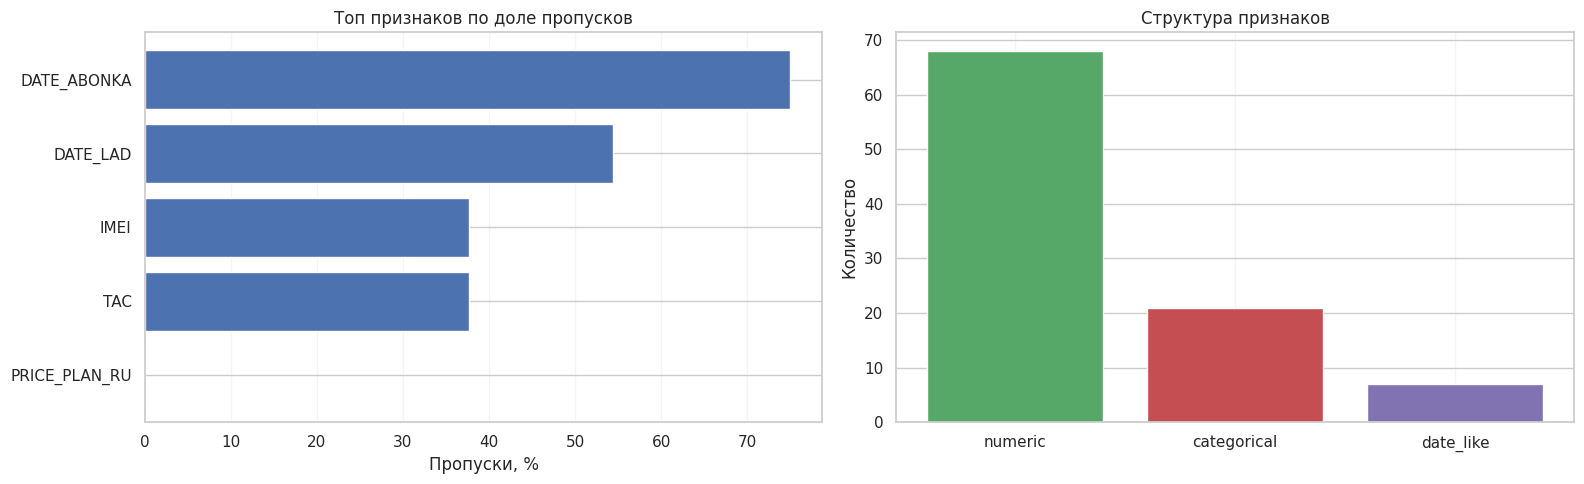

Комментарий: сначала убеждаемся, что нет дублей по идентификатору и критических проблем качества данных. Служебные колонки split-а исключены из профиля, чтобы статистика отражала только исходный месячный срез.


In [11]:
display(Markdown("## 1. Профиль данных и первичная диагностика"))

service_columns = {"experiment_group", "split_hash"}
source_columns = [column for column in df_final.columns if column not in service_columns]
source_df = df_final[source_columns].copy()

id_col = detect_id_column(source_df)
numeric_cols, categorical_cols, date_like_cols = infer_feature_buckets(source_df, id_col=id_col)
categorical_balance_cols, excluded_categorical_features = select_categorical_features_for_balance(source_df, categorical_cols)
duplicate_id_count = int(source_df[id_col].duplicated().sum())

profile_overview = pd.DataFrame(
    {
        "metric": [
            "Количество строк",
            "Количество столбцов в исходном срезе",
            "Идентификатор для разбиения",
            "Числовые признаки",
            "Категориальные признаки",
            "Категориальные признаки для chi-square",
            "Признаки, похожие на даты",
            "Дубликаты по идентификатору",
        ],
        "value": [
            len(source_df),
            source_df.shape[1],
            id_col,
            len(numeric_cols),
            len(categorical_cols),
            len(categorical_balance_cols),
            len(date_like_cols),
            duplicate_id_count,
        ],
    }
)
display(profile_overview)

missing_report = (
    pd.DataFrame(
        {
            "feature": source_df.columns,
            "dtype": [str(source_df[column].dtype) for column in source_df.columns],
            "missing_pct": [source_df[column].isna().mean() * 100 for column in source_df.columns],
            "unique_values": [source_df[column].nunique(dropna=True) for column in source_df.columns],
        }
    )
    .sort_values(["missing_pct", "unique_values"], ascending=[False, False])
    .reset_index(drop=True)
)

constant_features = missing_report.loc[missing_report["unique_values"] <= 1, "feature"].tolist()
high_cardinality_features = missing_report.loc[
    (missing_report["dtype"] == "object") & (missing_report["unique_values"] > MAX_CATEGORY_UNIQUE_VALUES),
    ["feature", "unique_values"],
].head(15)

display(Markdown("### Топ признаков по пропускам"))
display(missing_report.head(20))

if constant_features:
    print(f"Константные признаки: {', '.join(constant_features[:10])}" + (" ..." if len(constant_features) > 10 else ""))
else:
    print("Константных признаков не найдено.")

if duplicate_id_count == 0:
    print(f"Дублей по {id_col} не найдено. Это хороший сигнал для детерминированного назначения в control/test.")
else:
    print(f"Найдено {duplicate_id_count:,} дублей по {id_col}. Перед продуктивным сплитом лучше прояснить, является ли срез строго subscriber-level.")

print(f"Для chi-square и категориальных графиков оставляем {len(categorical_balance_cols)} признаков с кардинальностью не выше {MAX_CATEGORY_UNIQUE_VALUES}.")

if not high_cardinality_features.empty:
    display(Markdown("### High-cardinality категориальные признаки"))
    display(high_cardinality_features)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
missing_plot = missing_report.loc[missing_report["missing_pct"] > 0].head(TOP_MISSING_FEATURES).sort_values("missing_pct", ascending=True)
if not missing_plot.empty:
    axes[0].barh(missing_plot["feature"], missing_plot["missing_pct"], color="#4C72B0")
    axes[0].set_xlabel("Пропуски, %")
else:
    axes[0].text(0.5, 0.5, "Признаков с пропусками нет", ha="center", va="center")
axes[0].set_title("Топ признаков по доле пропусков")
axes[0].set_ylabel("")

type_counts = pd.Series(
    {
        "numeric": len(numeric_cols),
        "categorical": len(categorical_cols),
        "date_like": len(date_like_cols),
    }
)
axes[1].bar(type_counts.index, type_counts.values, color=["#55A868", "#C44E52", "#8172B2"])
axes[1].set_title("Структура признаков")
axes[1].set_ylabel("Количество")
for axis in axes:
    axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

print("Комментарий: сначала убеждаемся, что нет дублей по идентификатору и критических проблем качества данных. Служебные колонки split-а исключены из профиля, чтобы статистика отражала только исходный месячный срез.")

## Баланс control / test

Ниже мы строим детерминированный split по `SUBS_ID`, затем отдельно проверяем:

- `SRM` на всей базе
- баланс числовых признаков через `SMD` и `KS`
- баланс категориальных признаков через `chi-square` и `Cramer's V`
- множественные проверки через `FDR`

Для тяжелых статистических тестов и графиков используется стратифицированная выборка из обеих групп. Это ускоряет расчеты и делает `KS` менее чувствительным к огромному `N`.

In [12]:
display(Markdown("## 2. Детерминированный split и автоматический отчет баланса"))

GROUP_COL = "experiment_group"
HASH_COL = "split_hash"

if GROUP_COL not in df_final.columns or HASH_COL not in df_final.columns:
    df_final[GROUP_COL], df_final[HASH_COL] = assign_experiment_group(
        df_final[id_col],
        control_share=CONTROL_SHARE,
        salt=SPLIT_SALT,
    )

split_stats = srm_test(df_final[GROUP_COL], control_share=CONTROL_SHARE)
split_summary = (
    df_final[GROUP_COL]
    .value_counts(dropna=False)
    .rename_axis("group")
    .reset_index(name="count")
)
split_summary["share"] = split_summary["count"] / split_summary["count"].sum()
display(split_summary)

feature_cols = [column for column in df_final.columns if column not in [HASH_COL]]
sampled_df = build_stratified_sample(df_final[feature_cols], GROUP_COL, sample_per_group=BALANCE_SAMPLE_PER_GROUP)

numeric_report = analyze_numeric_balance(sampled_df, GROUP_COL, numeric_cols)
categorical_report = analyze_categorical_balance(sampled_df, GROUP_COL, categorical_balance_cols)
balance_report = add_balance_flags(pd.concat([numeric_report, categorical_report], ignore_index=True, sort=False))

balance_summary = pd.DataFrame(
    {
        "metric": [
            "SRM p-value",
            "Фактическая доля control",
            "Фактическая доля test",
            "Числовых признаков проверено",
            "Категориальных признаков проверено",
            "High-cardinality категориальных исключено",
            "Признаков с практическим дисбалансом",
            "Признаков значимых после FDR",
        ],
        "value": [
            split_stats["p_value"],
            split_stats["control_share_observed"],
            split_stats["test_share_observed"],
            int((balance_report["feature_type"] == "numeric").sum()),
            int((balance_report["feature_type"] == "categorical").sum()),
            int(len(excluded_categorical_features)),
            int(balance_report["practical_imbalance"].sum()),
            int(balance_report["significant_after_fdr"].sum()),
        ],
    }
)
display(balance_summary)

display(Markdown("### Топ признаков с наибольшим риском дисбаланса"))
display(
    balance_report[
        [
            "feature",
            "feature_type",
            "effect_size_name",
            "effect_size",
            "p_value",
            "fdr_q_value",
            "practical_imbalance",
            "significant_after_fdr",
        ]
    ].head(20)
)

numeric_balance_report = balance_report[balance_report["feature_type"] == "numeric"].copy()
categorical_balance_report = balance_report[balance_report["feature_type"] == "categorical"].copy()

if not excluded_categorical_features.empty:
    display(Markdown("### Исключенные из категориального баланса признаки"))
    display(excluded_categorical_features.head(15))

print_balance_commentary(split_stats, balance_report)
print(f"Для статистических тестов используется стратифицированная выборка по {BALANCE_SAMPLE_PER_GROUP:,} строк на группу.")

## 2. Детерминированный split и автоматический отчет баланса

,group,count,share
0,test,2629022,0.8999
1,control,292345,0.1001


,metric,value
0,SRM p-value,0.6846
1,Фактическая доля control,0.1001
2,Фактическая доля test,0.8999
3,Числовых признаков проверено,68.0000
4,Категориальных признаков проверено,14.0000
5,High-cardinality категориальных исключено,7.0000
6,Признаков с практическим дисбалансом,0.0000
7,Признаков значимых после FDR,0.0000


### Топ признаков с наибольшим риском дисбаланса

,feature,feature_type,effect_size_name,effect_size,p_value,fdr_q_value,practical_imbalance,significant_after_fdr
34,REVENUE_OUT_INT_VOICE,numeric,abs_smd,0.0091,1.0000,1.0000,False,False
71,PRICE_PLAN,categorical,cramers_v,0.0074,0.2871,1.0000,False,False
72,PRICE_PLAN_RU,categorical,cramers_v,0.0074,0.2871,1.0000,False,False
43,INTERCONNECT_LOC_IN,numeric,abs_smd,0.0071,0.5845,1.0000,False,False
13,USAGE_OUT_INT_VOICE,numeric,abs_smd,0.0070,1.0000,1.0000,False,False
54,USAGE_NUM_INC,numeric,abs_smd,0.0069,0.9818,1.0000,False,False
27,USAGE_IN_OFFNET_MEGACOM_VOICE,numeric,abs_smd,0.0067,0.9194,1.0000,False,False
16,USAGE_IN_OFFNET_VOICE,numeric,abs_smd,0.0061,0.8540,1.0000,False,False
7,COUNT_RECHARGE,numeric,abs_smd,0.0060,1.0000,1.0000,False,False
59,ROLY_GLOBAL,numeric,abs_smd,0.0057,1.0000,1.0000,False,False


### Исключенные из категориального баланса признаки

,feature,unique_values,selected_for_balance
0,CTN,2921232,False
1,IMEI,1693815,False
2,TAC,31731,False
3,CELL_ID,18016,False
4,CELL_MAX,17795,False
5,DEV_NAME,8266,False
6,PREV_PRICE_PLAN,247,False


### Краткая интерпретация

SRM не обнаружен: p-value = 0.6846, доля control = 10.0071%.
Признаков с практическим дисбалансом: 0. Признаков, оставшихся значимыми после FDR: 0.
Ориентир по интерпретации: для numeric обычно целимся в |SMD| < 0.1, для categorical смотрим на низкий Cramer's V и отсутствие массовых значимых расхождений после FDR.
Для статистических тестов используется стратифицированная выборка по 120,000 строк на группу.


## 3. Графики для визуальной проверки

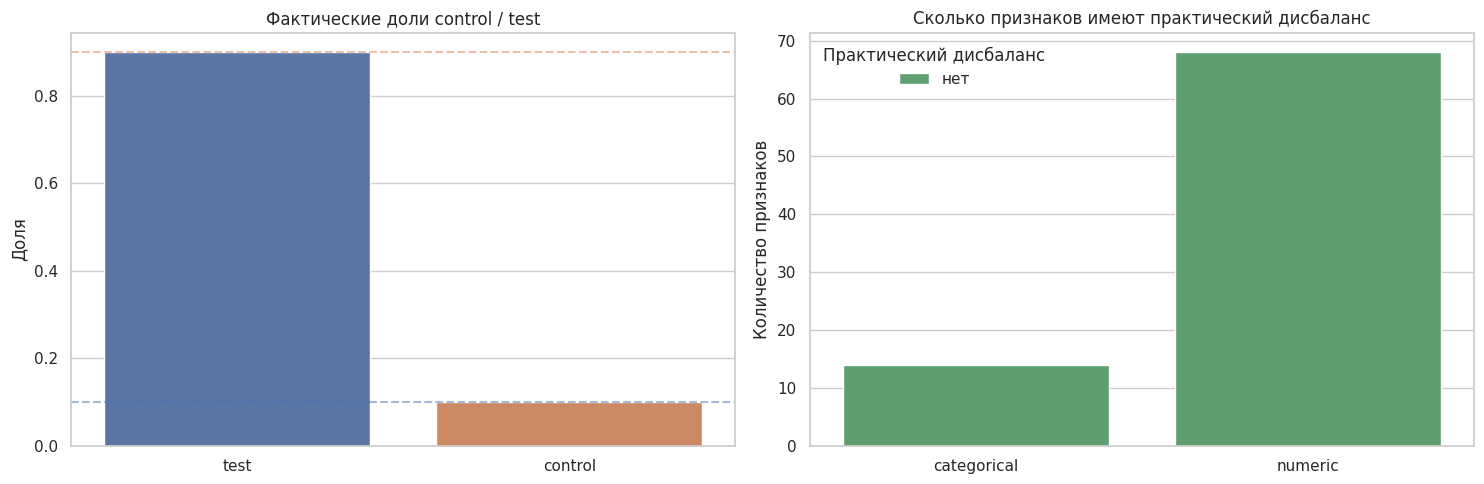

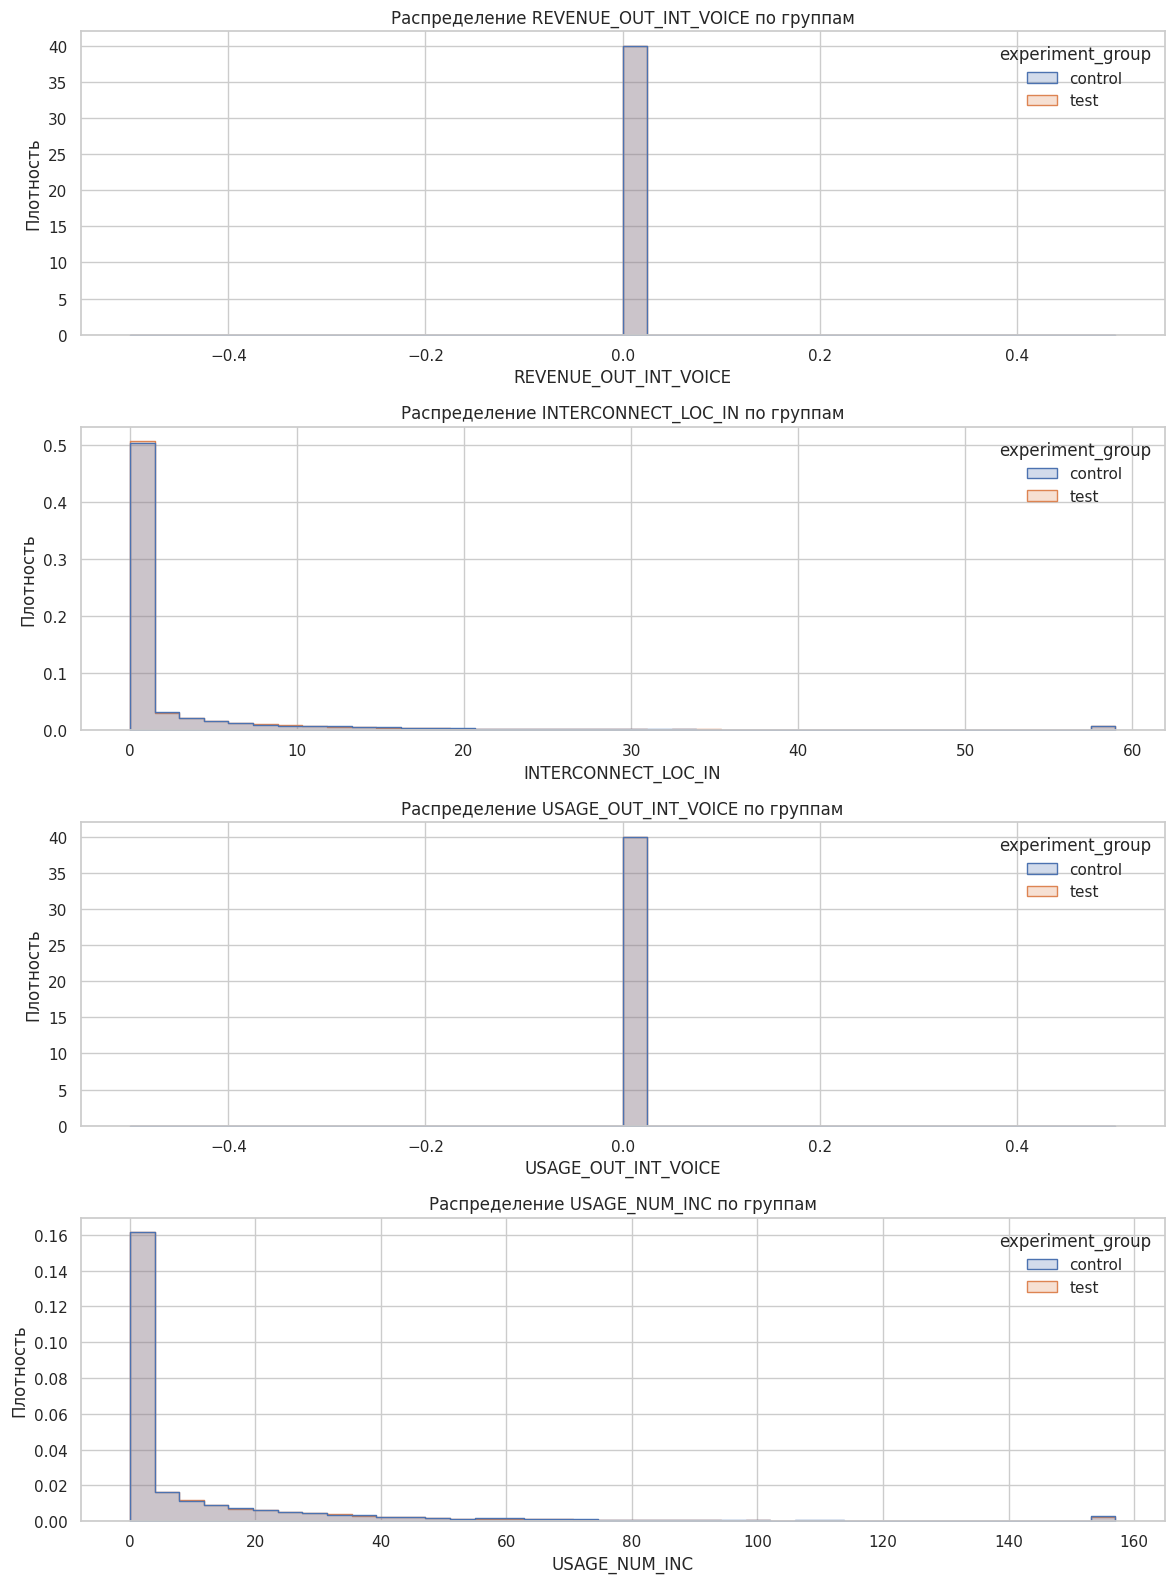

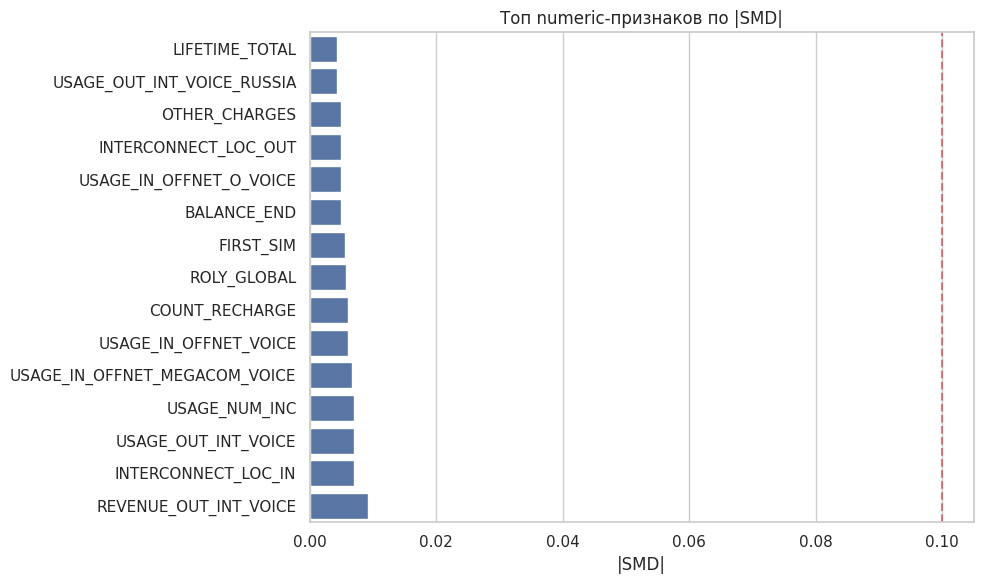

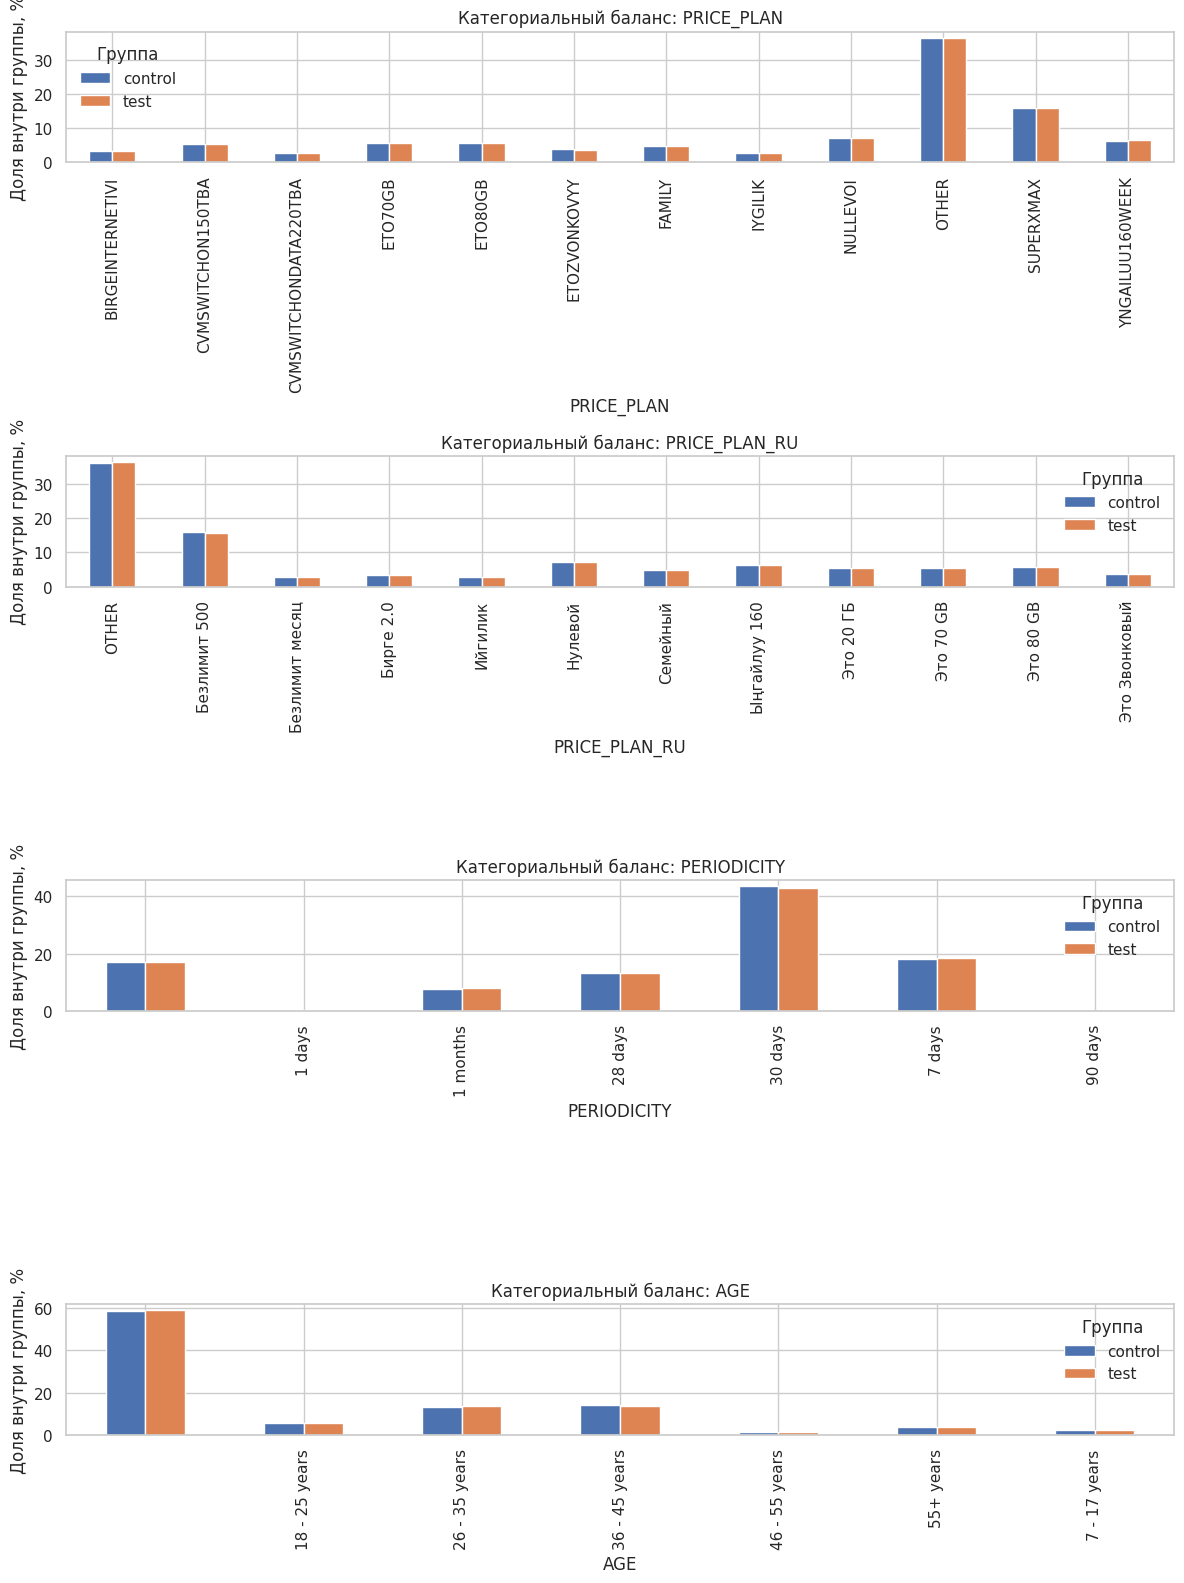

Комментарий: если столбики и распределения по control/test визуально близки, а в таблице нет массовых отклонений по |SMD| и FDR, сплит можно считать достаточно ровным для дальнейшего A/B-контроля.


In [13]:
display(Markdown("## 3. Графики для визуальной проверки"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=split_summary, x="group", y="share", hue="group", dodge=False, ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Фактические доли control / test")
axes[0].set_xlabel("")
axes[0].set_ylabel("Доля")
axes[0].axhline(CONTROL_SHARE, color="#4C72B0", linestyle="--", alpha=0.5)
axes[0].axhline(1 - CONTROL_SHARE, color="#DD8452", linestyle="--", alpha=0.5)

balance_counts = balance_report.groupby(["feature_type", "practical_imbalance"]).size().reset_index(name="count")
balance_counts["practical_imbalance"] = balance_counts["practical_imbalance"].map({True: "есть", False: "нет"})
sns.barplot(data=balance_counts, x="feature_type", y="count", hue="practical_imbalance", ax=axes[1], palette=["#55A868", "#C44E52"])
axes[1].set_title("Сколько признаков имеют практический дисбаланс")
axes[1].set_xlabel("")
axes[1].set_ylabel("Количество признаков")
axes[1].legend(title="Практический дисбаланс")
plt.tight_layout()
plt.show()

plot_sample = build_stratified_sample(sampled_df, GROUP_COL, sample_per_group=PLOT_SAMPLE_PER_GROUP)

top_numeric_features = numeric_balance_report.head(TOP_NUMERIC_PLOTS)["feature"].tolist()
if top_numeric_features:
    fig, axes = plt.subplots(len(top_numeric_features), 1, figsize=(12, 4 * len(top_numeric_features)))
    if len(top_numeric_features) == 1:
        axes = [axes]

    for axis, feature in zip(axes, top_numeric_features):
        plot_df = plot_sample[[GROUP_COL, feature]].dropna().copy()
        low, high = plot_df[feature].quantile([0.01, 0.99])
        plot_df[feature] = plot_df[feature].clip(lower=low, upper=high)
        sns.histplot(
            data=plot_df,
            x=feature,
            hue=GROUP_COL,
            bins=40,
            stat="density",
            common_norm=False,
            element="step",
            ax=axis,
        )
        axis.set_title(f"Распределение {feature} по группам")
        axis.set_xlabel(feature)
        axis.set_ylabel("Плотность")
    plt.tight_layout()
    plt.show()
else:
    print("Не найдено числовых признаков для визуального сравнения.")

plot_numeric_table = numeric_balance_report[["feature", "effect_size", "p_value", "fdr_q_value"]].head(15).copy()
if not plot_numeric_table.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_numeric_table.sort_values("effect_size", ascending=True), x="effect_size", y="feature", color="#4C72B0")
    plt.axvline(0.10, color="#C44E52", linestyle="--", alpha=0.7)
    plt.title("Топ numeric-признаков по |SMD|")
    plt.xlabel("|SMD|")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

top_categorical_features = categorical_balance_report.head(TOP_CATEGORICAL_PLOTS)["feature"].tolist()
if top_categorical_features:
    fig, axes = plt.subplots(len(top_categorical_features), 1, figsize=(12, 4 * len(top_categorical_features)))
    if len(top_categorical_features) == 1:
        axes = [axes]

    for axis, feature in zip(axes, top_categorical_features):
        prepared = reduce_categories(plot_sample[feature], max_levels=MAX_CATEGORY_LEVELS)
        distribution = pd.crosstab(prepared, plot_sample[GROUP_COL], normalize="columns").mul(100)
        distribution.plot(kind="bar", ax=axis, color=["#4C72B0", "#DD8452"])
        axis.set_title(f"Категориальный баланс: {feature}")
        axis.set_xlabel(feature)
        axis.set_ylabel("Доля внутри группы, %")
        axis.legend(title="Группа")
    plt.tight_layout()
    plt.show()
else:
    print("Не найдено категориальных признаков для визуального сравнения.")

print("Комментарий: если столбики и распределения по control/test визуально близки, а в таблице нет массовых отклонений по |SMD| и FDR, сплит можно считать достаточно ровным для дальнейшего A/B-контроля.")